In [1]:
from pathlib import Path

import equinox as eqx
import grain
import jax
import matplotlib.pyplot as plt
from context_flux_no.data import TheWellDataSource
from context_flux_no.training.io import load_model
from tqdm import tqdm


import os

os.environ["CUDA_VISIBLE_DEVICES"] = "2"
os.environ["JAX_CUDA_VISIBLE_DEVICES"] = "0"

os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

import jax

print(jax.local_devices())

[CudaDevice(id=0)]


In [16]:
checkpoint_dir = Path("../../checkpoints/cubicflux_2d/")

model_paths = {
    # "DPOT": "seed=10/26-04-30-04:59:06",
    # "HyperFluxFNOLocal": "seed=10/26-04-30-01:34:48",
    "DISCO": "seed=10/26-07-22-11:21:43",
    "HyperFluxFNOLocal": "seed=10/26-07-21-18:43:01",
}

In [3]:
from pathlib import Path
from typing import Optional

import hydra
import jax
import xarray as xr
from context_flux_no.models.multiphysics import (
    AbstractMultiphysicsOperator,
    HyperFluxFNO,
    HyperFluxFNOLocal,
)
from context_flux_no.training.loader import SegmentLoaderBackground
from context_flux_no.training.loss import PushforwardOneStepLoss
from context_flux_no.training.trainer import Trainer
from omegaconf import DictConfig, OmegaConf


def get_coordinate_spacing(dataset: xr.Dataset, coordinate: str) -> float:
    """Return the uniform spacing of a dataset coordinate."""
    if coordinate not in dataset.coords:
        raise ValueError(
            f"Dataset does not contain the required coordinate '{coordinate}'. "
            f"Available coordinates: {list(dataset.coords)}"
        )

    values = dataset[coordinate]

    if values.size < 2:
        raise ValueError(f"Coordinate '{coordinate}' must contain at least two points.")

    return float(values[1] - values[0])


def validate_spatial_2d_dataset(dataset: xr.Dataset) -> None:
    """Validate that the dataset has time and two spatial coordinates."""
    required_coordinates = ("t", "x", "y")
    missing = [
        coordinate
        for coordinate in required_coordinates
        if coordinate not in dataset.coords
    ]

    if missing:
        raise ValueError(
            f"Dataset is missing required coordinates: {missing}. "
            f"Available coordinates: {list(dataset.coords)}"
        )


def get_loss_args(
    model: AbstractMultiphysicsOperator,
    dataset: xr.Dataset,
) -> Optional[tuple[float, float, float]]:
    """
    Return time and 2D spatial grid spacing for flux-based models.

    The returned tuple is:
        (dt, dx, dy)
    """
    if isinstance(model, (HyperFluxFNO, HyperFluxFNOLocal)):
        validate_spatial_2d_dataset(dataset)

        dt = get_coordinate_spacing(dataset, "t")
        dx = get_coordinate_spacing(dataset, "x")
        dy = get_coordinate_spacing(dataset, "y")

        return dt, dx, dy

    return None


@hydra.main(config_path="./configs", config_name="config", version_base=None)
def main(cfg: DictConfig) -> None:
    # Manually select the GPU to run on.
    if cfg.gpu_id != "auto":
        gpu_id = int(cfg.gpu_id)
        gpu_devices = jax.devices("gpu")

        if gpu_id < 0 or gpu_id >= len(gpu_devices):
            raise ValueError(
                f"Invalid gpu_id={gpu_id}. "
                f"Available GPU indices: 0-{len(gpu_devices) - 1}"
            )

        jax.config.update("jax_default_device", gpu_devices[gpu_id])

    model = hydra.utils.instantiate(cfg.model)

    dataset_train = xr.open_dataset(
        cfg.data.loadpath_train,
        engine="h5netcdf",
        chunks={},
    ).isel(t=slice(0, cfg.data.max_train_time_index))

    dataset_valid = xr.open_dataset(
        cfg.data.loadpath_valid,
        engine="h5netcdf",
        chunks={},
    ).isel(t=slice(0, cfg.data.max_train_time_index))

    validate_spatial_2d_dataset(dataset_train)
    validate_spatial_2d_dataset(dataset_valid)

    loss_fn = hydra.utils.instantiate(cfg.loss_fn)

    if isinstance(loss_fn, PushforwardOneStepLoss):
        # Context frames + one pushforward prediction frame + one target frame.
        segment_length = cfg.training.context_length + 2
    else:
        # Context frames + one target frame.
        segment_length = cfg.training.context_length + 1

    loader_train = SegmentLoaderBackground(
        dataset_train,
        segment_length,
        cfg.training.batch_size,
        cfg.training.batches_per_load,
        cfg.training.queue_capacity,
    )

    loader_valid = SegmentLoaderBackground(
        dataset_valid,
        segment_length,
        cfg.training.batch_size,
        cfg.training.batches_per_load,
        cfg.training.queue_capacity,
    )

    trainer = Trainer(
        hydra.utils.instantiate(cfg.training.optimizer),
        loss_fn,
        Path(cfg.training.checkpoint_dir) / cfg.data.name,
        checkpoint_name=(
            Path(model.__class__.__name__)
            / loss_fn.__class__.__name__
            / f"seed={cfg.model.key.seed}"
        ),
        wandb_kwargs=cfg.wandb_kwargs,
        config_dict=OmegaConf.to_container(
            cfg,
            resolve=True,
            throw_on_missing=True,
        ),  # ty: ignore[invalid-argument-type]
    )

    trainer.train(
        model=model,
        train_dataloader=loader_train,
        validation_dataloader=loader_valid,
        loss_args=get_loss_args(model, dataset_train),
        num_steps=cfg.training.max_steps,
    )

In [4]:
dataset_valid = xr.open_dataset(
    "/home/taeyoungkim/CONTEXT_FLUX_NO/data/2d_cubic_test_100_100.hdf5",
    engine="h5netcdf",
    chunks={},
).isel(t=slice(0, 80))

validate_spatial_2d_dataset(dataset_valid)

In [75]:
loader_valid = SegmentLoaderBackground(
    dataset_valid,
    40,
    20,
    20,
    20,
)

In [76]:
dataiter = iter(loader_valid)
batch = next(dataiter)

In [77]:
batch.shape

(20, 40, 1, 50, 50)

In [88]:
u_pred_dict = {}

traj_idx = 100
max_batches = 20

for model_type, path in tqdm(model_paths.items()):
    model = load_model(checkpoint_dir / model_type / "OneStepLoss" / path)
    model = eqx.nn.inference_mode(model, True)

    u_pred_dict[model_type] = []

    for batch_idx, batch in enumerate(dataiter):
        if batch_idx >= max_batches:
            break

        context, u_data = batch[:, :20], batch[:, 20:]

        u_pred = eqx.filter_vmap(
            lambda x, y: model.rollout(
                x,
                (0.005, 1 / 50),
                num_steps=len(y),
            )[0]
        )(context, u_data)

        u_pred_dict[model_type].append(u_pred)

  0%|                                                                                                                                                                                                                                                      | 0/2 [00:00<?, ?it/s]/home/taeyoungkim/CONTEXT_FLUX_NO/.venv/lib/python3.12/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1269: UserWarning: Sharding info not provided when restoring. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(
 50%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                                                                                                                      | 1/2 [13:35<13:35, 815.65s/it]/home/taeyoung

In [128]:
u_pred_dict["DISCO"].shape
u_pred_dict["HyperFluxFNOLocal"].shape

AttributeError: 'list' object has no attribute 'shape'

TypeError: list indices must be integers or slices, not tuple

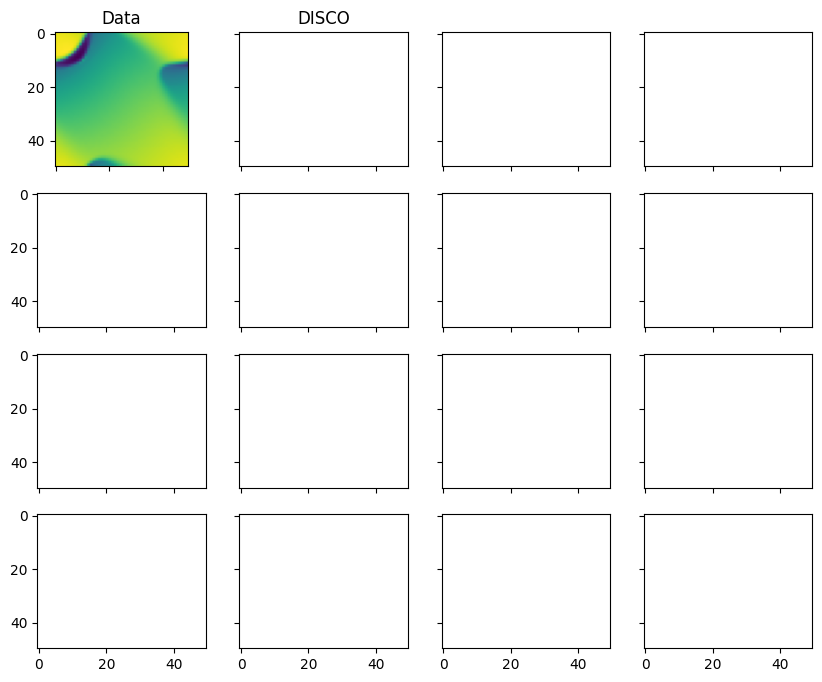

In [89]:
t_idx = 0
sample_idx = 80
fig, axes = plt.subplots(4, 4, figsize=(10, 8), sharex=True, sharey=True)
axes[0, 0].set_title("Data")
for j in range(4):
    axes[j, 0].imshow(u_data[sample_idx, t_idx, j])
    for i, (model_name, u_pred) in enumerate(u_pred_dict.items()):
        axes[0, i + 1].set_title(model_name)
        axes[j, i + 1].imshow(u_pred[sample_idx, t_idx, j])
fig.suptitle(f"Rollout={t_idx + 1} step(s)")

TypeError: list indices must be integers or slices, not tuple

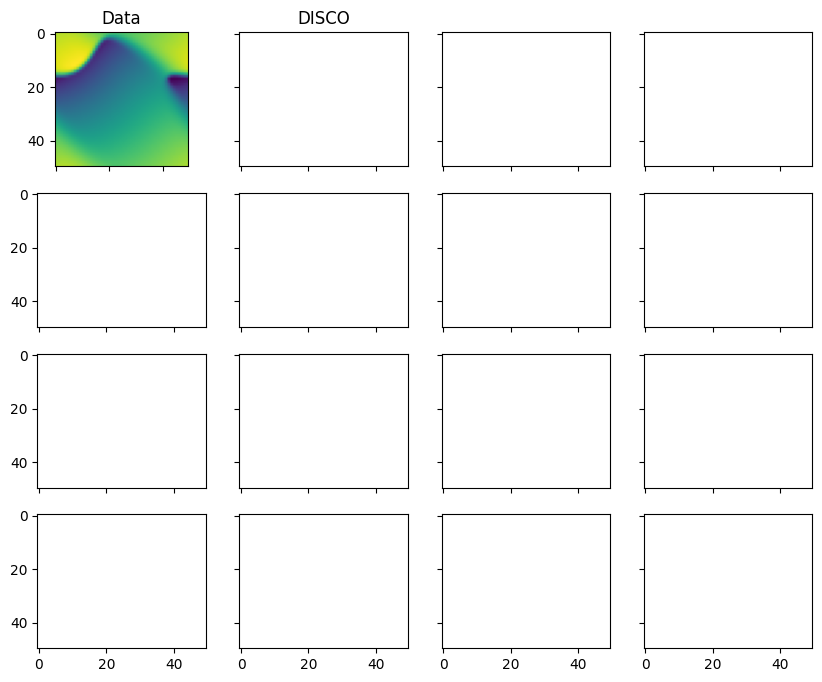

In [90]:
t_idx = 19
sample_idx = 80
fig, axes = plt.subplots(4, 4, figsize=(10, 8), sharex=True, sharey=True)
axes[0, 0].set_title("Data")
for j in range(4):
    axes[j, 0].imshow(u_data[sample_idx, t_idx, j])
    for i, (model_name, u_pred) in enumerate(u_pred_dict.items()):
        axes[0, i + 1].set_title(model_name)
        axes[j, i + 1].imshow(u_pred[sample_idx, t_idx, j])
fig.suptitle(f"Rollout={t_idx + 1} step(s)")

In [129]:
import jax.numpy as jnp
from context_flux_no.metrics import relative_L2_error


jax.tree.map(
    lambda x: jnp.mean(
        eqx.filter_vmap(relative_L2_error)(x[:,], u_data.reshape(-1, 1, 50, 50))
    ),
    jnp.array(u_pred_dict["DISCO"])[-1].reshape(-1, 1, 50, 50),
)

Array(1.4671615, dtype=float32)

In [130]:
import jax.numpy as jnp
from context_flux_no.metrics import relative_L2_error


jax.tree.map(
    lambda x: jnp.mean(
        eqx.filter_vmap(relative_L2_error)(x[:,], u_data.reshape(-1, 1, 50, 50))
    ),
    jnp.array(u_pred_dict["HyperFluxFNOLocal"])[-1].reshape(-1, 1, 50, 50),
)

Array(0.26503772, dtype=float32)

In [121]:
u_data.shape

(20, 20, 1, 50, 50)

u_pred_dict.shape

In [125]:
jnp.array(u_pred_dict["DISCO"])[:, :, -1, :].reshape(-1, 1, 50, 50).shape

(400, 1, 50, 50)

In [117]:
u_data.shape

(20, 20, 1, 50, 50)